# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [36]:
%load_ext autoreload

from NM_TinyRNN.code.models import training
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import save_data
from NM_TinyRNN.code.models import submit_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:

# let's test some code!
test_data_path = DATA_PATH / "bayes_optimal"
test_save_path  = './NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy'
reload(save_data)
reload(ds)
reload(nc)
reload(rnns)
reload(training)

input_encoding = 'unipolar'
input_forced_choice = False

subject_data_path = DATA_PATH/'WS08'
#ws_subject_list = ['WS01','WS02','WS05','WS08','WS09','WS10','WS13','WS14','WS16','WS18','WS20','WS22']
dataset = ds.AB_Dataset(subject_data_path,sequence_length = 64,
                        input_encoding=input_encoding,input_forced_choice=input_forced_choice)
input_size = dataset.inputs.shape[-1]
model = rnns.TinyRNN(rnn_type = 'monoGRU', nonlinearity = 'softplus', hidden_size = 2, init_decoder = False,
                     input_size=input_size, input_encoding=input_encoding,input_forced_choice = input_forced_choice,
                     decoder_bias = False)

# we use a trainer with ensemble model training across hyperparameters
trainer = training.Trainer(weight_seeds = list(range(1,51)),
                        sparsity_lambdas = [1e-1,1e-2,1e-3,1e-4,1e-5],
                        energy_lambdas = [1e-1,1e-2,1e-3],
                        hebbian_lambdas = [0.0],
                        covariance_lambdas = [0.0],
                        batch_size = 128)
final_state_dict, config, loss_dict = trainer.fit(model, dataset)


Sequence length 64 excludes 7.6% of trials
Parallelizing 750 models on cpu
Data split (session-level): 13 train, 2 validation, and 2 evaluation


  6%|▌         | 589/10000 [04:43<1:15:26,  2.08it/s]


KeyboardInterrupt: 

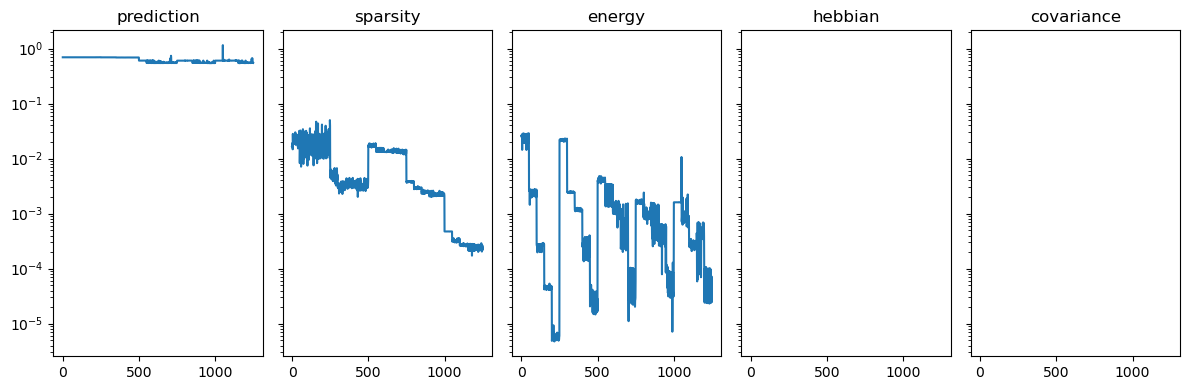

In [68]:
#plot losses
fig, ax = plt.subplots(1,len([x for x in loss_dict.keys()]), sharey=True, figsize=(12,4))
for i, (k,v) in enumerate(loss_dict.items()):
    ax[i].semilogy(np.arange(len(v)),v)
    ax[i].set_title(k)
plt.tight_layout()

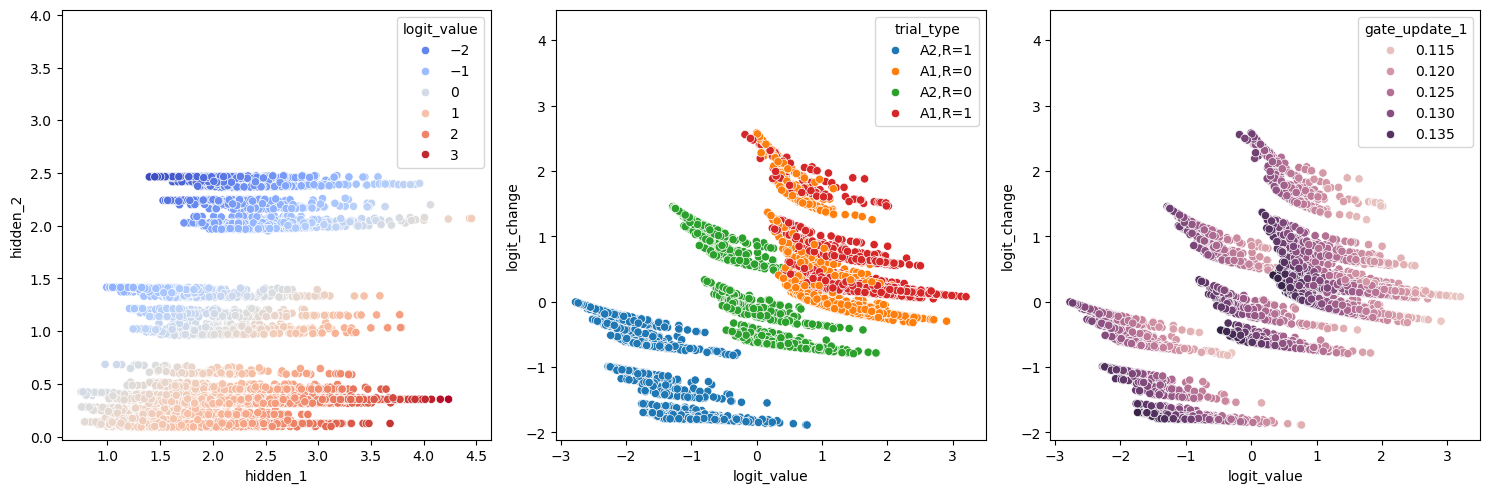

In [69]:
# let's look at a logit plot
model.load_state_dict(final_state_dict)
reload(save_data)
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset, splits['inner_folds'][0])
fig, ax = plt.subplots(1,3, figsize = (15,5))
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='hidden_1', y='hidden_2', 
                hue='logit_value', palette='coolwarm', 
                ax =ax[0])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='trial_type', ax =ax[1])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='gate_update_1', ax = ax[2])
[x.axis('square') for x in ax]
fig.tight_layout()

In [70]:
print(config)
final_state_dict

(0.001, 1e-05, 0.0, 0.0, 33)


{'rnn.W_ih': tensor([[0.7588, 3.0482],
         [0.7208, 1.4560]], grad_fn=<SelectBackward0>),
 'rnn.W_hh': tensor([[ 0.9276,  0.0068],
         [-0.6268,  0.0951]], grad_fn=<SelectBackward0>),
 'rnn.W_iz': tensor([[-0.0017],
         [-0.0066]], grad_fn=<SelectBackward0>),
 'rnn.W_hz': tensor([[-0.0638],
         [ 0.0019]], grad_fn=<SelectBackward0>),
 'rnn.bias_h': tensor([-0.1249, -2.3743], grad_fn=<SelectBackward0>),
 'rnn.bias_z': tensor(-1.7797, grad_fn=<SelectBackward0>),
 'rnn.hidden_0': tensor([ 1.3727e+00, -2.6966e-04], grad_fn=<SelectBackward0>),
 'rnn.z_0': tensor([3.2684e-05], grad_fn=<SelectBackward0>),
 'decoder.weight': tensor([[ 1.0037, -0.0025],
         [ 0.0019,  1.7759]], grad_fn=<SelectBackward0>)}

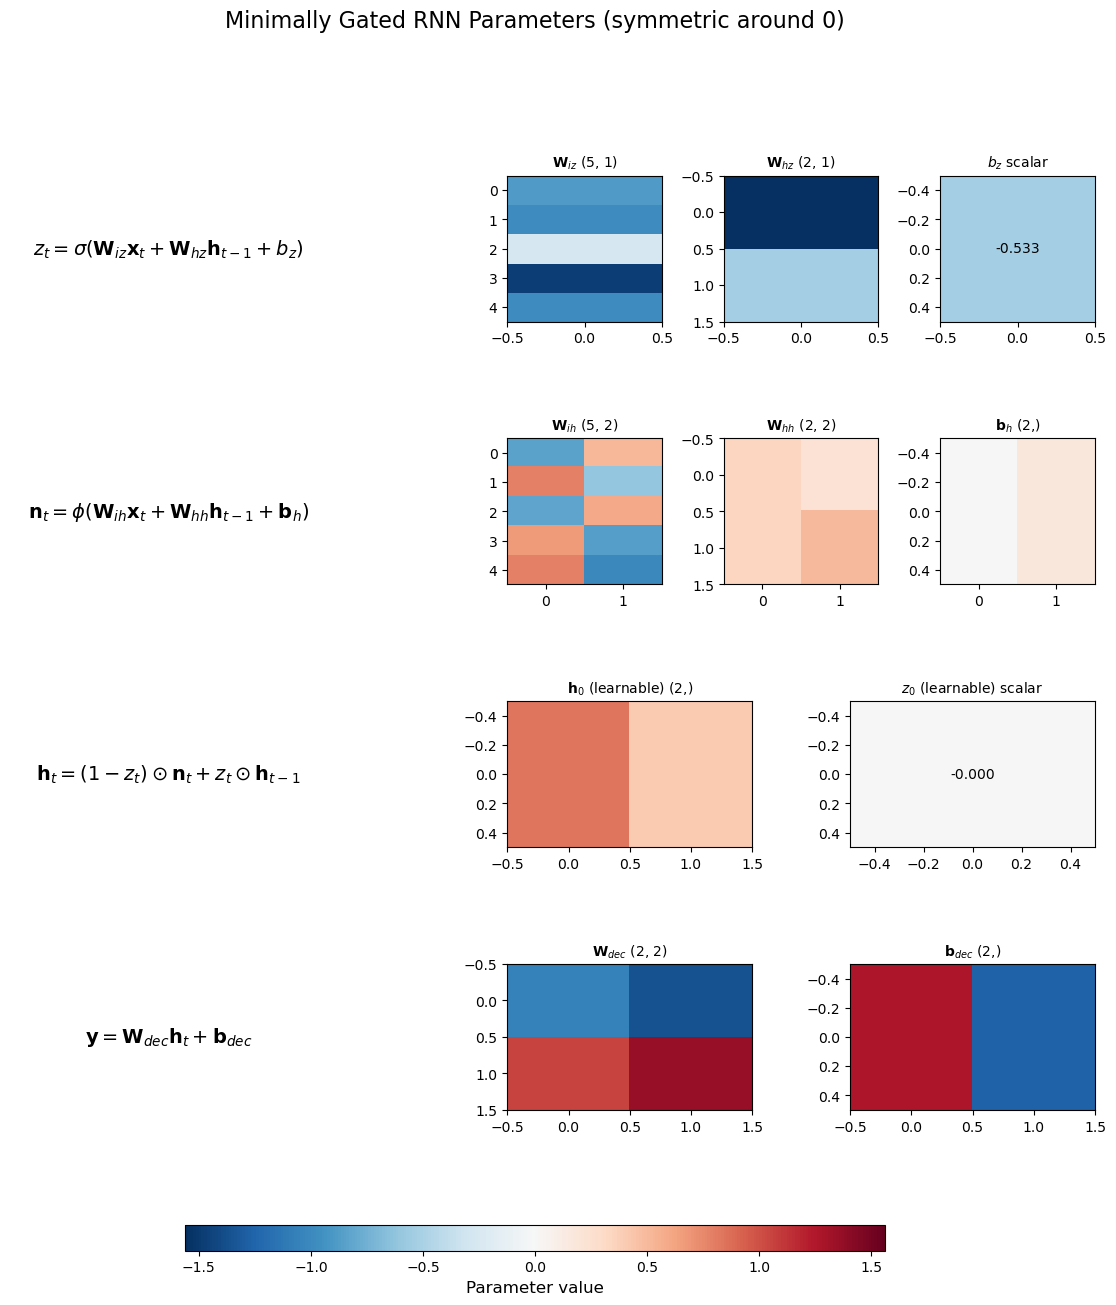

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import torch  # in case you still have tensor parameters

def plot_rnn_parameters(param_dict, include_decoder=False):
    """
    Visualise the parameters of a minimally gated RNN.
    
    Parameters
    ----------
    param_dict : dict
        Dictionary containing the RNN parameters. Expected keys:
        'rnn.W_ih', 'rnn.W_hh', 'rnn.W_iz', 'rnn.W_hz',
        'rnn.bias_h', 'rnn.bias_z', 'rnn.hidden_0', 'rnn.z_0'.
        If include_decoder=True, also 'decoder.weight' and 'decoder.bias'.
    include_decoder : bool
        Whether to add an extra row for the decoder weights.
    """
    # Convert all tensors to numpy arrays (if needed)
    clean_dict = {}
    for k, v in param_dict.items():
        if isinstance(v, torch.Tensor):
            v = v.detach().cpu().numpy()
        else:
            v = np.asarray(v)   # ensure it's a numpy array
        clean_dict[k] = v

    # Gather all values to compute symmetric colour range
    all_vals = []
    for arr in clean_dict.values():
        all_vals.append(arr.ravel())
    all_vals = np.concatenate(all_vals)
    max_abs = max(abs(all_vals.min()), abs(all_vals.max()))
    vmin, vmax = -max_abs, max_abs

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.RdBu_r

    # Determine number of rows (add one for decoder if requested)
    n_rows = 3 + (1 if include_decoder else 0)
    fig = plt.figure(figsize=(14, 3.2 * n_rows))
    gs = GridSpec(n_rows, 2, figure=fig, width_ratios=[0.35, 0.65],
                  hspace=0.8, wspace=0.4, bottom=0.15)

    # ---------- helper to annotate scalars safely ----------
    def scalar_text(ax, val, pos=(0, 0)):
        """Place text on a 1x1 heatmap."""
        ax.text(pos[0], pos[1], f'{float(val):.3f}',
                ha='center', va='center',
                color='white' if abs(float(val)) > max_abs/2 else 'black')

    # ---------- First row: z_t ----------
    ax_eq1 = fig.add_subplot(gs[0, 0])
    ax_eq1.axis('off')
    eq1 = (r"$z_t = \sigma\left(\mathbf{W}_{iz}\mathbf{x}_t + "
           r"\mathbf{W}_{hz}\mathbf{h}_{t-1} + b_z\right)$")
    ax_eq1.text(0.5, 0.5, eq1, ha='center', va='center', fontsize=14,
                transform=ax_eq1.transAxes)

    subgs_z = gs[0, 1].subgridspec(1, 3, wspace=0.4)
    ax_Wiz = fig.add_subplot(subgs_z[0, 0])
    im_Wiz = ax_Wiz.imshow(clean_dict['rnn.W_iz'], aspect='auto', cmap=cmap, norm=norm)
    ax_Wiz.set_title(r'$\mathbf{W}_{iz}$ ' + str(clean_dict['rnn.W_iz'].shape), fontsize=10)

    ax_Whz = fig.add_subplot(subgs_z[0, 1])
    im_Whz = ax_Whz.imshow(clean_dict['rnn.W_hz'], aspect='auto', cmap=cmap, norm=norm)
    ax_Whz.set_title(r'$\mathbf{W}_{hz}$ ' + str(clean_dict['rnn.W_hz'].shape), fontsize=10)

    ax_bz = fig.add_subplot(subgs_z[0, 2])
    bz_val = clean_dict['rnn.bias_z'].item()  # extract scalar
    im_bz = ax_bz.imshow(np.atleast_2d(bz_val), aspect='auto', cmap=cmap, norm=norm)
    ax_bz.set_title(r'$b_z$ scalar', fontsize=10)
    scalar_text(ax_bz, bz_val)

    # ---------- Second row: n_t ----------
    ax_eq2 = fig.add_subplot(gs[1, 0])
    ax_eq2.axis('off')
    eq2 = (r"$\mathbf{n}_t = \phi\left(\mathbf{W}_{ih}\mathbf{x}_t + "
           r"\mathbf{W}_{hh}\mathbf{h}_{t-1} + \mathbf{b}_h\right)$")
    ax_eq2.text(0.5, 0.5, eq2, ha='center', va='center', fontsize=14,
                transform=ax_eq2.transAxes)

    subgs_n = gs[1, 1].subgridspec(1, 3, wspace=0.4)
    ax_Wih = fig.add_subplot(subgs_n[0, 0])
    im_Wih = ax_Wih.imshow(clean_dict['rnn.W_ih'], aspect='auto', cmap=cmap, norm=norm)
    ax_Wih.set_title(r'$\mathbf{W}_{ih}$ ' + str(clean_dict['rnn.W_ih'].shape), fontsize=10)

    ax_Whh = fig.add_subplot(subgs_n[0, 1])
    im_Whh = ax_Whh.imshow(clean_dict['rnn.W_hh'], aspect='auto', cmap=cmap, norm=norm)
    ax_Whh.set_title(r'$\mathbf{W}_{hh}$ ' + str(clean_dict['rnn.W_hh'].shape), fontsize=10)

    ax_bh = fig.add_subplot(subgs_n[0, 2])
    bh_vals = clean_dict['rnn.bias_h']  # shape (H,)
    im_bh = ax_bh.imshow(bh_vals.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm)
    ax_bh.set_title(r'$\mathbf{b}_h$ ' + str(bh_vals.shape), fontsize=10)

    # ---------- Third row: h_t + initial states ----------
    ax_eq3 = fig.add_subplot(gs[2, 0])
    ax_eq3.axis('off')
    eq3 = (r"$\mathbf{h}_t = (1-z_t)\odot\mathbf{n}_t + "
           r"z_t\odot\mathbf{h}_{t-1}$")
    ax_eq3.text(0.5, 0.5, eq3, ha='center', va='center', fontsize=14,
                transform=ax_eq3.transAxes)

    subgs_h = gs[2, 1].subgridspec(1, 2, wspace=0.4)
    ax_h0 = fig.add_subplot(subgs_h[0, 0])
    h0_vals = clean_dict['rnn.hidden_0']  # shape (H,)
    im_h0 = ax_h0.imshow(h0_vals.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm)
    ax_h0.set_title(r'$\mathbf{h}_{0}$ (learnable) ' + str(h0_vals.shape), fontsize=10)

    ax_z0 = fig.add_subplot(subgs_h[0, 1])
    z0_val = clean_dict['rnn.z_0'].item()  # extract scalar
    im_z0 = ax_z0.imshow(np.atleast_2d(z0_val), aspect='auto', cmap=cmap, norm=norm)
    ax_z0.set_title(r'$z_{0}$ (learnable) scalar', fontsize=10)
    scalar_text(ax_z0, z0_val)

    # ---------- Optional decoder row ----------
    if include_decoder:
        row = 3
        ax_eq4 = fig.add_subplot(gs[row, 0])
        ax_eq4.axis('off')
        eq4 = (r"$\mathbf{y} = \mathbf{W}_{dec}\mathbf{h}_t + \mathbf{b}_{dec}$")
        ax_eq4.text(0.5, 0.5, eq4, ha='center', va='center', fontsize=14,
                    transform=ax_eq4.transAxes)

        subgs_dec = gs[row, 1].subgridspec(1, 2, wspace=0.4)
        ax_Wdec = fig.add_subplot(subgs_dec[0, 0])
        Wdec = clean_dict['decoder.weight']
        im_Wdec = ax_Wdec.imshow(Wdec, aspect='auto', cmap=cmap, norm=norm)
        ax_Wdec.set_title(r'$\mathbf{W}_{dec}$ ' + str(Wdec.shape), fontsize=10)

        ax_bdec = fig.add_subplot(subgs_dec[0, 1])
        bdec = clean_dict['decoder.bias']
        im_bdec = ax_bdec.imshow(bdec.reshape(1, -1), aspect='auto', cmap=cmap, norm=norm)
        ax_bdec.set_title(r'$\mathbf{b}_{dec}$ ' + str(bdec.shape), fontsize=10)

    # ---------- Single shared colorbar ----------
    cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.02])
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax,
                        orientation='horizontal')
    cbar.set_label('Parameter value', fontsize=12)

    fig.suptitle('Minimally Gated RNN Parameters (symmetric around 0)', fontsize=16, y=1.01)
    plt.show()

# ------------------------------------------------------------------
# Example usage with your final_state_dict

# Plot without the decoder (the default)
plot_rnn_parameters(final_state_dict, include_decoder=True)

# Or with the decoder row
# plot_rnn_parameters(final_state_dict, include_decoder=True)

In [ ]:
#Here we've got code to run all inner loops in parallel,  

outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 1,
                                  n_outer_loops = 3,
                                  save_path = test_save_path,
                                  trainer_kwargs = {'weight_seeds':list(range(1,11)),
                                                'sparsity_lambdas':[1e-1,1e-2,1e-3,1e-4,1e-5],
                                                 'energy_lambdas':[1e-1,1e-2,1e-3],
                                                 'hebbian_lambdas':[0.0],
                                                 'covariance_lambdas':[0.0]} )

print([d['val_loss'] for d in outer_results['inner_results']])


## Training on HPC


In [94]:
from NM_TinyRNN.code.models import submit_jobs
reload(submit_jobs)
#we load a dataframe with the subjects we want to train
info_df = submit_jobs.get_ws_all_info_df()
info_df[info_df.completed==0]

,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,input_encoding,input_forced_choice,nm_size,nm_dim,nm_mode,model_id,save_path,data_path,completed
40,WS_all,1,stereoGRU,1,relu,energy,unipolar,True,1,1,row,1_unit_stereoGRU_relu_unipolar_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
41,WS_all,1,stereoGRU,2,relu,energy,unipolar,True,1,1,row,2_unit_stereoGRU_relu_unipolar_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
42,WS_all,1,stereoGRU,1,relu,energy,unipolar,False,1,1,row,1_unit_stereoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
43,WS_all,1,stereoGRU,2,relu,energy,unipolar,False,1,1,row,2_unit_stereoGRU_relu_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
44,WS_all,1,stereoGRU,1,relu,energy,onehot,True,1,1,row,1_unit_stereoGRU_relu_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,WS_all,10,stereoGRUx,2,tanh,sparsity,unipolar,False,1,1,row,2_unit_stereoGRUx_tanh_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
876,WS_all,10,stereoGRUx,1,tanh,sparsity,onehot,True,1,1,row,1_unit_stereoGRUx_tanh_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
877,WS_all,10,stereoGRUx,2,tanh,sparsity,onehot,True,1,1,row,2_unit_stereoGRUx_tanh_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
878,WS_all,10,stereoGRUx,1,tanh,sparsity,onehot,False,1,1,row,1_unit_stereoGRUx_tanh_onehot,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0


In [20]:
reload(submit_jobs)
submit_jobs.run_training(overwrite = False, test=True)

Submitting model training for WS_all to HPC
Submitted batch job 3021539
Submitting model training for WS_all to HPC
Submitted batch job 3021540
Submitting model training for WS_all to HPC
Submitted batch job 3021541
Submitting model training for WS_all to HPC
Submitted batch job 3021542
Submitting model training for WS_all to HPC
Submitted batch job 3021543
Submitting model training for WS_all to HPC
Submitted batch job 3021544
Submitting model training for WS_all to HPC
Submitted batch job 3021545
Submitting model training for WS_all to HPC
Submitted batch job 3021546
Submitting model training for WS_all to HPC
Submitted batch job 3021547
Submitting model training for WS_all to HPC
Submitted batch job 3021548
Submitting model training for WS_all to HPC
Submitted batch job 3021549
Submitting model training for WS_all to HPC
Submitted batch job 3021550
Submitting model training for WS_all to HPC
Submitted batch job 3021551
Submitting model training for WS_all to HPC
Submitted batch job 